# Ridge Plots

## Used libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data

In [3]:
all_thickness = []
all_r1 = []
all_r2 = []
all_A = []
all_B = []
all_C = []
all_D = []
all_E = []
all_alpha = []
all_beta = []
all_lambda = []
all_ne = []

In [4]:
for r in range(1, 6):
    all_thickness.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/thickness.npy'.format(r))
    )

    all_r1.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/r1.npy'.format(r))
    )
    all_r2.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/r2.npy'.format(r))
    )

    all_A.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/A.npy'.format(r))
    )
    all_B.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/B.npy'.format(r))
    )
    all_C.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/C.npy'.format(r))
    )
    all_D.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/D.npy'.format(r))
    )
    all_E.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/E.npy'.format(r))
    )

    all_alpha.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/alpha.npy'.format(r))
    )
    all_beta.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/beta.npy'.format(r))
    )
    all_lambda.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/lambda.npy'.format(r))
    )

    all_ne.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/data/R{}/ne.npy'.format(r))
    )

In [5]:
params = []

for i in range(0, 5):
    params.append(
        np.load('/content/drive/MyDrive/AzONet/notebooks/2_de/bins/region_{}.npy'.format(i))
    )

## Seaborn

In [6]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
    "figure.dpi": 300,           # Default DPI for new figures
    "savefig.dpi": 300,          # DPI when saving figures

    # Font settings
    "font.family": "sans-serif",     # Universal font family
    "font.size": 11,                   # Base font size

    # Title and label sizes
    "axes.titlesize": 16,             # Axis title size
    "axes.titleweight": "bold",       # Axis title weight
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "semibold",   # Axis label weight

    # -------------------------------------------------

    # Tick LABEL sizes (text next to ticks)
    "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
    "ytick.labelsize": 11,       # Size of y-axis tick labels

    # Tick MARK sizes (physical marks on axes)
    "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
    "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

    # Additional tick parameters you might want to use:
    "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
    "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

    # Tick WIDTH (thickness)
    "xtick.major.width": 1,      # Width/Thickness of major ticks
    "ytick.major.width": 1,      # Width/Thickness of major ticks

    # Tick PADDING (distance from label to tick)
    "xtick.major.pad": 3.5,      # Padding between x-tick and label
    "ytick.major.pad": 3.5,      # Padding between y-tick and label

    # Tick DIRECTIONS
    "xtick.direction": "out",    # "in", "out", or "inout"
    "ytick.direction": "out",    # Points outward from axis

    # Tick COLORS
    "xtick.color": "black",      # Color of x-axis ticks and labels
    "ytick.color": "black",      # Color of y-axis ticks and labels

    # MINOR ticks (for more granular scales)
    "xtick.minor.visible": False,  # Show minor x-ticks
    "ytick.minor.visible": False,  # Show minor y-ticks

    # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
    "xtick.top": False,          # Show ticks on top of plot
    "xtick.bottom": True,        # Show ticks on bottom (default: True)
    "ytick.left": True,          # Show ticks on left (default: True)
    "ytick.right": False,        # Show ticks on right

    # ---------------------------------

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
    "legend.framealpha":0.9,

    # Figure title (for suptitle)
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # ----------------------------------

    # Figure border
    #"figure.edgecolor": "black",
    #"figure.frameon": True,
    #"figure.linewidth": 2.0,

    # Axes borders (spines)
    "axes.linewidth": 1.0,           # Width of axis lines
    "axes.edgecolor": "black",       # Color of axis lines

    # Individual spine control via rcParams
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,

    # ----------------------------
    # Patch properties (for histograms, bars, kde fills, etc.)
    "patch.linewidth": 1.5,           # Default linewidth for patches
    "patch.edgecolor": "black",       # Default edge color
    "patch.facecolor": "blue",        # Default fill color (careful with this!)
    "patch.force_edgecolor": True,    # Always show edges

    "axes.grid": False,           # Turn off grid completely

})

## Plot

In [7]:
len(params), params[0].shape

(5, (5, 12))

In [8]:
full = np.vstack(params)
full.shape

(145, 12)

In [9]:
all_values = [
    all_thickness,
    all_r1,
    all_r2,
    all_A,
    all_B,
    all_C,
    all_D,
    all_E,
    all_alpha,
    all_beta,
    all_lambda,
    all_ne
]

In [10]:
from scipy.stats import gaussian_kde


def plot_kde_normalized(ax, data, color, alpha=0.4, lw=1, label:str = ''):
    data = data[~np.isnan(data)]

    sns.kdeplot(data=data, ax=ax, fill=True, alpha=alpha,
                linewidth=lw, color=color, clip = [np.min(data), np.max(data)], label = label)

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

names = [
    'Espesor [nm]',
    r'$\sigma_1$ [nm]',
    r'$\sigma_2$ [nm]',
    'A',
    'B',
    'C [nm]',
    'D',
    'E [nm]',
    r'$\alpha_0$ [nm]$^{⁻1}$',
    r'$\beta$ [eV]$^{-1}$',
    r'$\lambda_g$ [nm]',
    r'$n_e$ [nm]$^{-3}$'
]

names_f = [
    'thickness',
    'sigma1',
    'sigma2',
    'A',
    'B',
    'C',
    'D',
    'E',
    'alpha',
    'beta',
    'lambda',
    'ne',
]

for _i in range(len(names)):
    control = 0
    # Put your arrays in a list
    _element = _i
    arrays = [ params[i_][:, _element] for i_ in range(0,5) ]

    labels = [
        r'$R_1$',
        r'$R_2$',
        r'$R_3$',
        r'$R_4$',
        r'$R_5$'
    ]

    plt.figure(figsize=(4, 4))

    # Create subplots
    fig, axes = plt.subplots(len(arrays), 1, figsize=(10, 8), sharex=True)
    fig.subplots_adjust(hspace=0.1)  # Adjust spacing to create overlap effect

    # Plot each distribution
    for i, (ax, array, label) in enumerate(zip(axes, arrays, labels)):

        plot_kde_normalized(
            ax=ax,
            data=array,
            color='blue',
            alpha=0.4,
            label = r'$\rho$'
        )

        plot_kde_normalized(
            ax=ax,
            data=all_values[_i][control],
            color='red',
            alpha=0.4,
            label = r'$\rho_{s}$'
        )

        ax.set_ylabel(label, rotation=0, ha='right', fontsize=28)
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)

        #ax.set_xlim(
        #    np.min(full[:, _i]),
        #    np.max(full[:, _i])
        #)

        if (_i in [3, 5, 6, 7, 10, 11]) and control==4 :
            ax.legend(fontsize = 18)

        elif (_i in [0, 1, 2, 4, 8, 9]) and control == 0:
            ax.legend(fontsize = 18)

        control += 1


    # Set common x-axis label
    axes[-1].set_xlabel(names[_i], fontsize = 28)
    axes[-1].tick_params(axis='x', labelsize=18)

    offset_text = axes[-1].xaxis.get_offset_text()
    offset_text.set_fontsize(18)  # Larger than tick labels

    plt.savefig('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/images/ridger_plot/{}.png'.format(names_f[_i]))
    plt.show()
    # _i se fija en el parametro y control en la region
    # Estan bien: Espesor, R1, R2, B, alpha, beta
    # A(5), C(5), D(5), E(5), lambda (5), ne(5)

Output hidden; open in https://colab.research.google.com to view.

In [12]:
_sellmeier = full[:, 3:8]
_sellmeier.shape

(145, 5)

In [13]:
_x = np.linspace(110e-9, 1100e-9, 911)

In [14]:
def refractive_index(x, A, B, C, D, E):

    n = A + (B*x**2)/(x**2 - C**2) + (D*x**2)/(x**2 - E**2)  # Get the n
    #print(n.shape)

    return np.mean(n)

In [15]:
_indice_de_refraccion = np.sqrt( np.array([ refractive_index(_x, *x) for x in _sellmeier ]) )
_indice_de_refraccion.shape

(145,)

In [16]:
bin_indices = [ np.load('/content/drive/MyDrive/AzONet/notebooks/2_de/bins/bin_index_{}.npy'.format(x)) for x in range(0,5)  ]
#bin_indices

In [17]:
n_region = []
for _bin in bin_indices:
    _arr = _indice_de_refraccion[_bin]
    print(_arr.shape)
    n_region.append(_arr)

(5,)
(46,)
(49,)
(12,)
(33,)


In [18]:
all_B[0].shape

(3000,)

In [19]:
n_full_regions = []

In [20]:
for i in range(0, 5): # This are the regions
    n_values = []
    for j in range(0, 3000):
        _n = np.sqrt(
            refractive_index(
            _x,
            all_A[i][j],
            all_B[i][j],
            all_C[i][j],
            all_D[i][j],
            all_E[i][j],
        ))
        n_values.append(_n)

    n_full_regions.append(n_values)

In [21]:
len(n_full_regions[0])

3000

<Figure size 1200x1200 with 0 Axes>

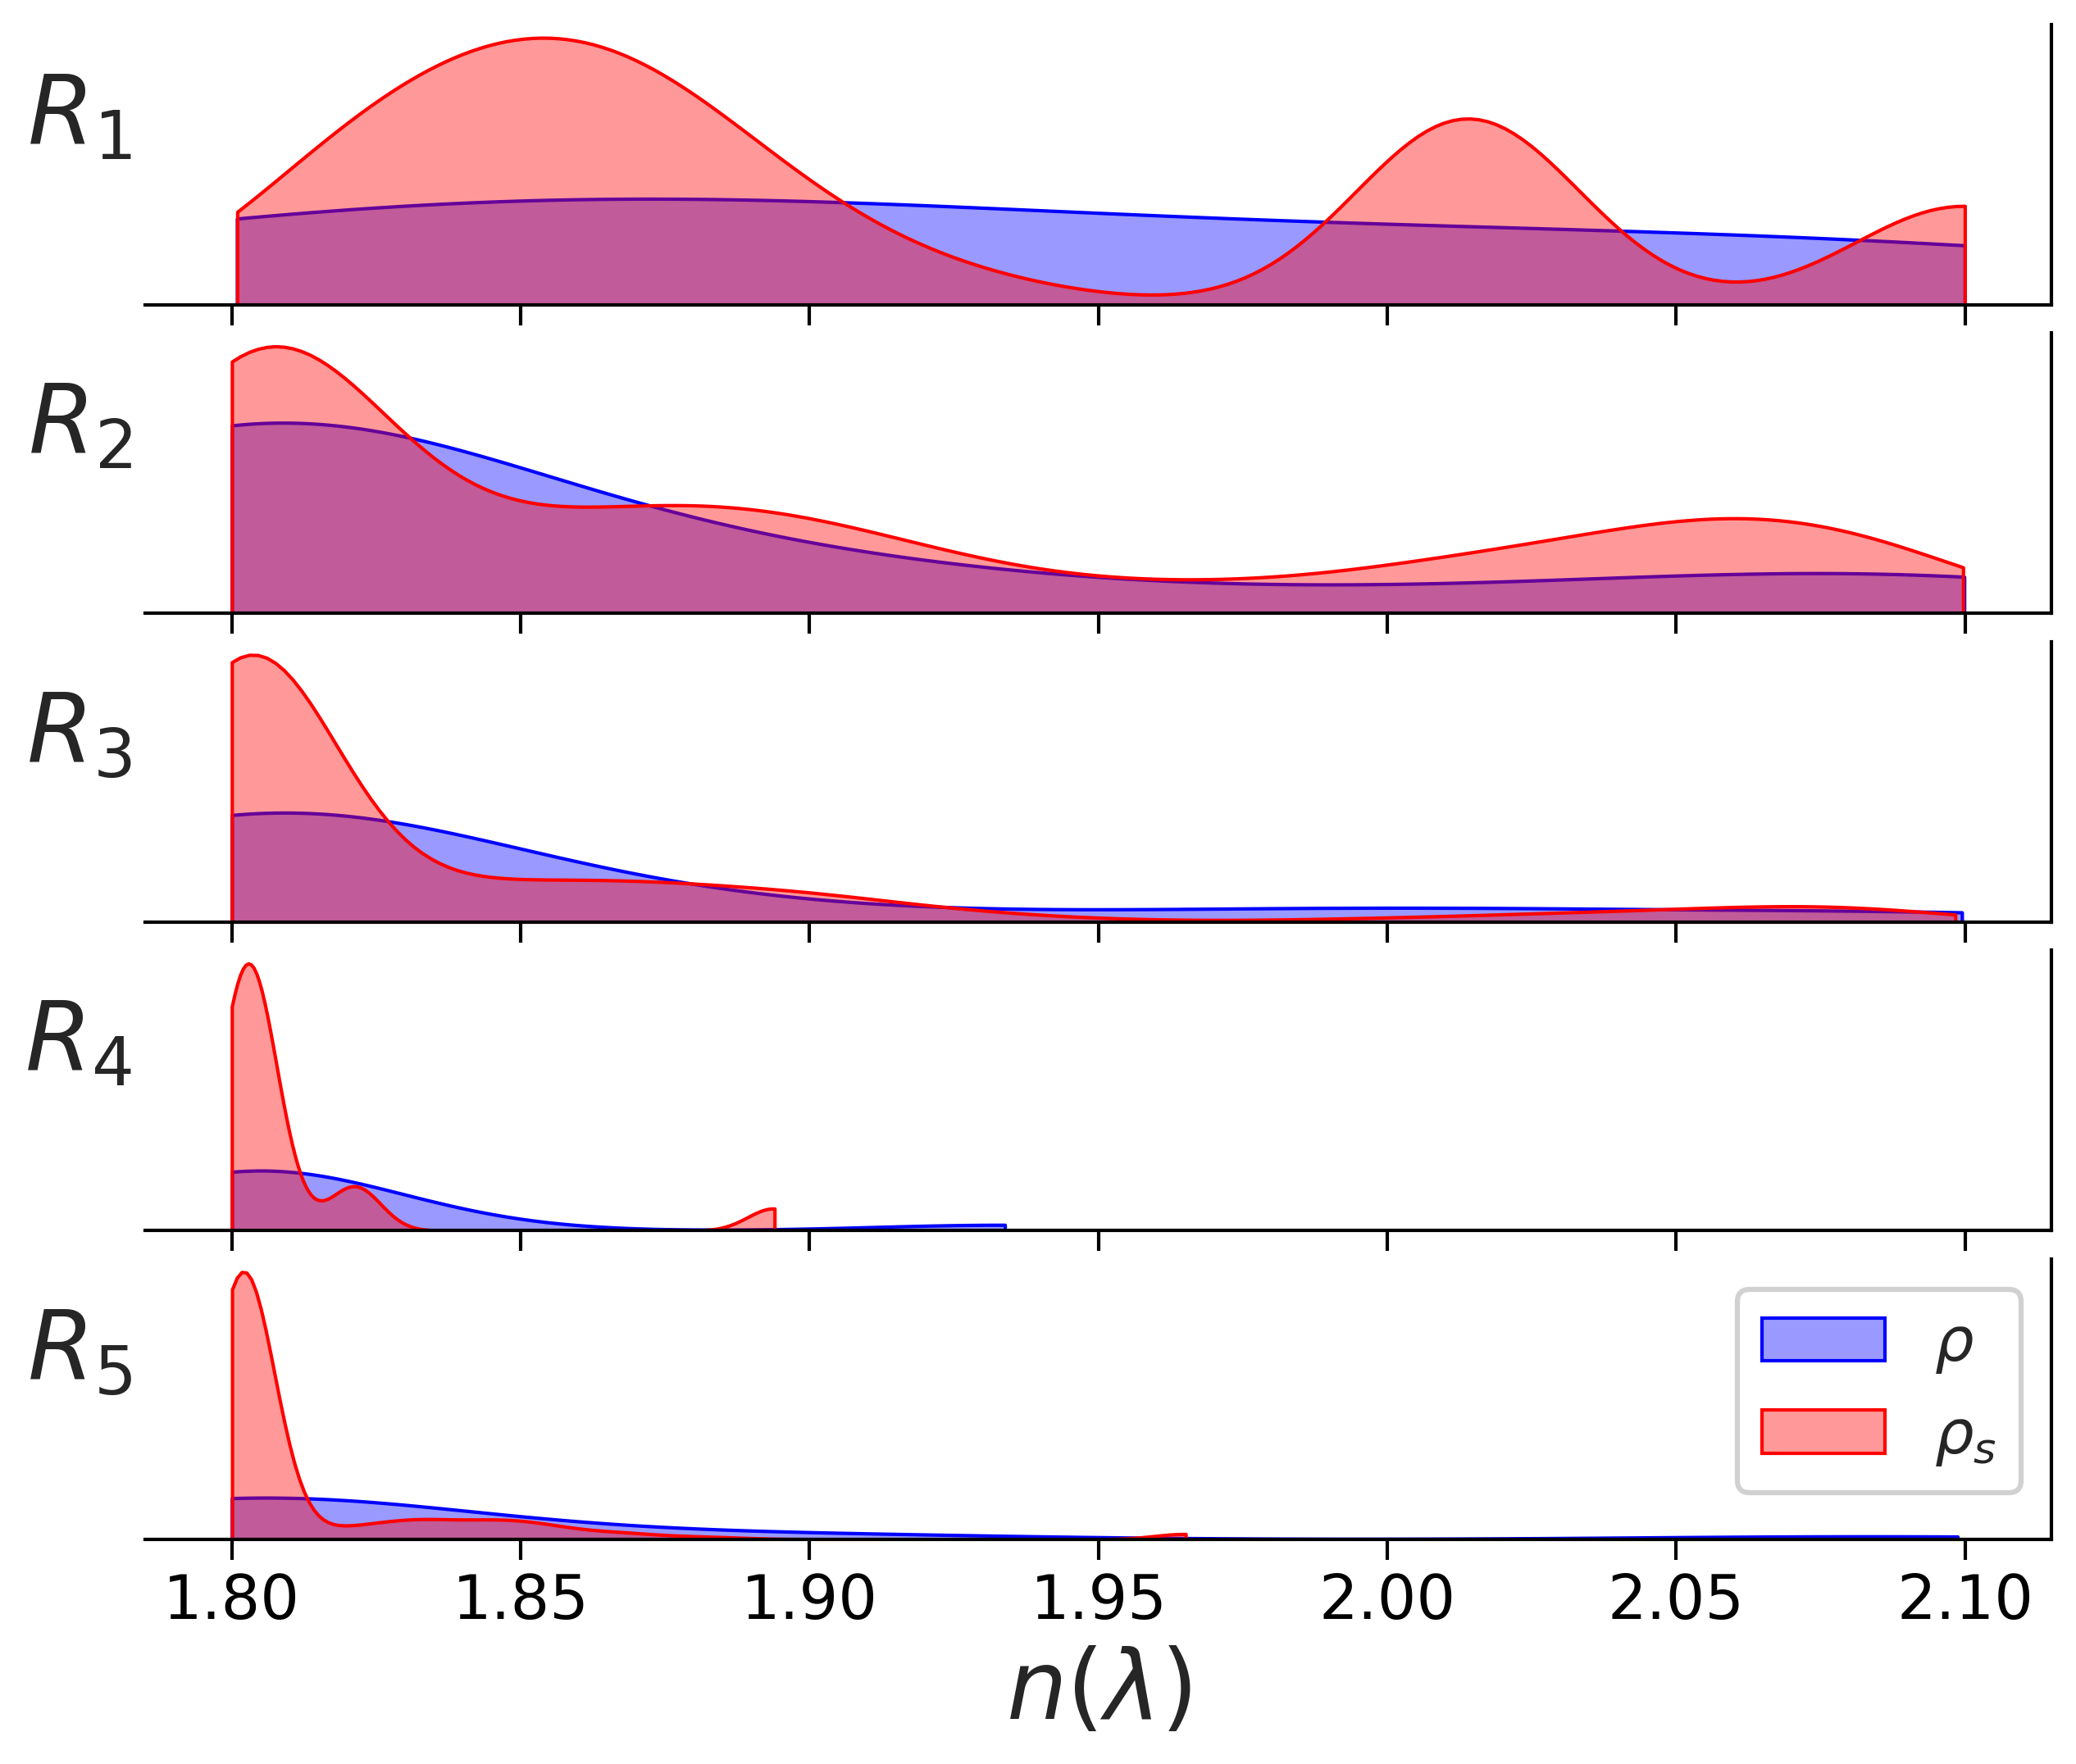

In [22]:
arrays = n_region

labels = [
    r'$R_1$',
    r'$R_2$',
    r'$R_3$',
    r'$R_4$',
    r'$R_5$'
]

plt.figure(figsize=(4, 4))

# Create subplots
fig, axes = plt.subplots(len(arrays), 1, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0.1)  # Adjust spacing to create overlap effect

# Plot each distribution
control = 0
for i, (ax, array, label) in enumerate(zip(axes, arrays, labels)):

# Create KDE plot
    plot_kde_normalized(
        ax=ax,
        data=array,
        color='blue',
        alpha=0.4,
        label = r'$\rho$'
    )

    plot_kde_normalized(
        ax=ax,
        data= np.array(n_full_regions[control]),
        color='red',
        alpha=0.4,
        label = r'$\rho_{s}$'
    )

    if control == 4:
        ax.legend(fontsize = 18)
    control +=1

    # Customize each subplot
    ax.set_ylabel(label, rotation=0, ha='right', fontsize = 28)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    #ax.set_xlim(
    #    np.min(_indice_de_refraccion),
    #    np.max(_indice_de_refraccion)
    #)

# Set common x-axis label
axes[-1].set_xlabel(r'$n(\lambda)$', fontsize = 28)
axes[-1].tick_params(axis='x', labelsize=18)
offset_text = axes[-1].xaxis.get_offset_text()
offset_text.set_fontsize(18)  # Larger than tick labels

plt.savefig('/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/images/ridger_plot/indice.png' )
plt.show()

## Join Images

In [23]:
from PIL import Image
import os
import glob

def create_simple_grid(image_folder, rows, cols, output_path="grid_output.png",
                      spacing=10, scale_factor=None, target_resolution=None):
    """
    Enhanced function to create image grid with resolution control

    Args:
        image_folder: Folder containing PNG images
        rows: Number of rows
        cols: Number of columns
        output_path: Output file path
        spacing: Space between images
        scale_factor: Reduce size by this factor (e.g., 0.5 for half size)
        target_resolution: Target max dimension in pixels (e.g., 1000 for 1000px max side)
    """
    # Get all PNG files
    image_files = glob.glob(os.path.join(image_folder, "*.png"))
    image_files.sort()  # Sort alphabetically

    if not image_files:
        print("No PNG files found!")
        return

    # Load images
    images = []
    for img_path in image_files[:rows*cols]:
        img = Image.open(img_path)

        # Apply resolution reduction if requested
        if scale_factor or target_resolution:
            img = reduce_resolution(img, scale_factor, target_resolution)

        images.append(img)

    # Get image dimensions (assuming all are same size after processing)
    img_width, img_height = images[0].size

    # Calculate grid size
    grid_width = cols * img_width + (cols - 1) * spacing
    grid_height = rows * img_height + (rows - 1) * spacing

    # Create blank image
    grid = Image.new('RGB', (grid_width, grid_height), color='white')

    # Paste images
    for idx, img in enumerate(images):
        row = idx // cols
        col = idx % cols

        x = col * (img_width + spacing)
        y = row * (img_height + spacing)

        grid.paste(img, (x, y))

    # Apply output quality reduction (for JPEG)
    if output_path.lower().endswith('.jpg') or output_path.lower().endswith('.jpeg'):
        grid.save(output_path, 'JPEG', quality=85, optimize=True)
    else:
        # For PNG, use optimize flag and optionally reduce palette
        grid.save(output_path, optimize=True)

    print(f"Grid created with {len(images)} images")
    print(f"Grid size: {grid_width}x{grid_height} pixels")
    print(f"Saved to: {output_path}")

    return grid

def reduce_resolution(image, scale_factor=None, target_resolution=None):
    """
    Reduce image resolution using different methods
    """
    original_width, original_height = image.size

    if scale_factor and 0 < scale_factor < 1:
        # Method 1: Scale by factor
        new_width = int(original_width * scale_factor)
        new_height = int(original_height * scale_factor)
        print(f"Scaling from {original_width}x{original_height} to {new_width}x{new_height}")

    elif target_resolution:
        # Method 2: Scale to target max dimension
        max_dimension = max(original_width, original_height)
        if max_dimension > target_resolution:
            scale = target_resolution / max_dimension
            new_width = int(original_width * scale)
            new_height = int(original_height * scale)
            print(f"Reducing to max {target_resolution}px: {original_width}x{original_height} → {new_width}x{new_height}")
        else:
            new_width, new_height = original_width, original_height

    else:
        # No reduction
        return image

    # Resize with high-quality downsampling
    return image.resize((new_width, new_height), Image.Resampling.LANCZOS)

def batch_reduce_resolution(image_folder, output_folder, scale_factor=None,
                           target_resolution=None, quality=85):
    """
    Pre-process all images in a folder to reduce resolution before creating grid
    """
    os.makedirs(output_folder, exist_ok=True)

    image_files = glob.glob(os.path.join(image_folder, "*.png"))

    for img_path in image_files:
        img = Image.open(img_path)
        img_reduced = reduce_resolution(img, scale_factor, target_resolution)

        # Save with quality settings
        output_path = os.path.join(output_folder, os.path.basename(img_path))
        if output_path.lower().endswith('.jpg') or output_path.lower().endswith('.jpeg'):
            img_reduced.save(output_path, 'JPEG', quality=quality, optimize=True)
        else:
            img_reduced.save(output_path, optimize=True)

    print(f"Reduced {len(image_files)} images saved to {output_folder}")






Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Grid created with 3 images
Grid size: 4500x1200 pixels
Saved to: combined_rugosidades.png


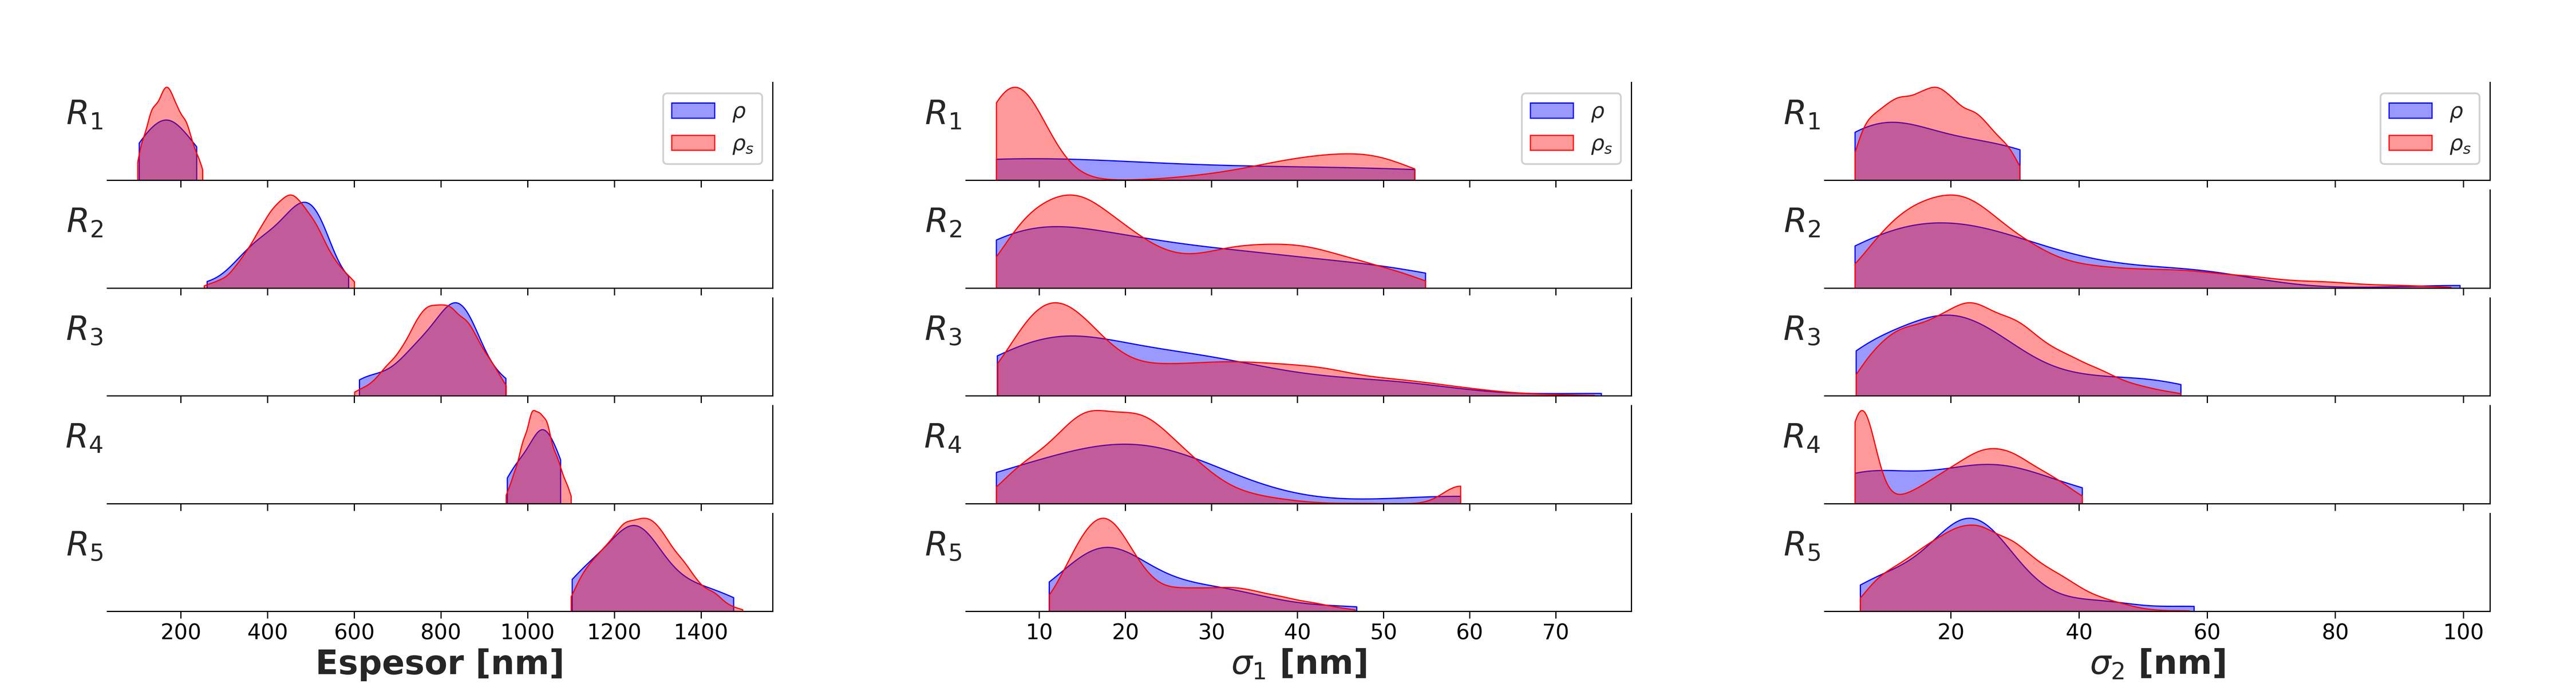

In [24]:
create_simple_grid(
    image_folder="/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/images/ridger_plot/rugosidades/",
    rows=1,  # 3 rows
    cols=3,  # 4 columns
    output_path="combined_rugosidades.png",
    spacing=0,  # 5 pixels spacing
    scale_factor=0.5  # Reduce each image to 50% before creating grid
)

Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Grid created with 4 images
Grid size: 3000x2400 pixels
Saved to: combined_absorcion.png


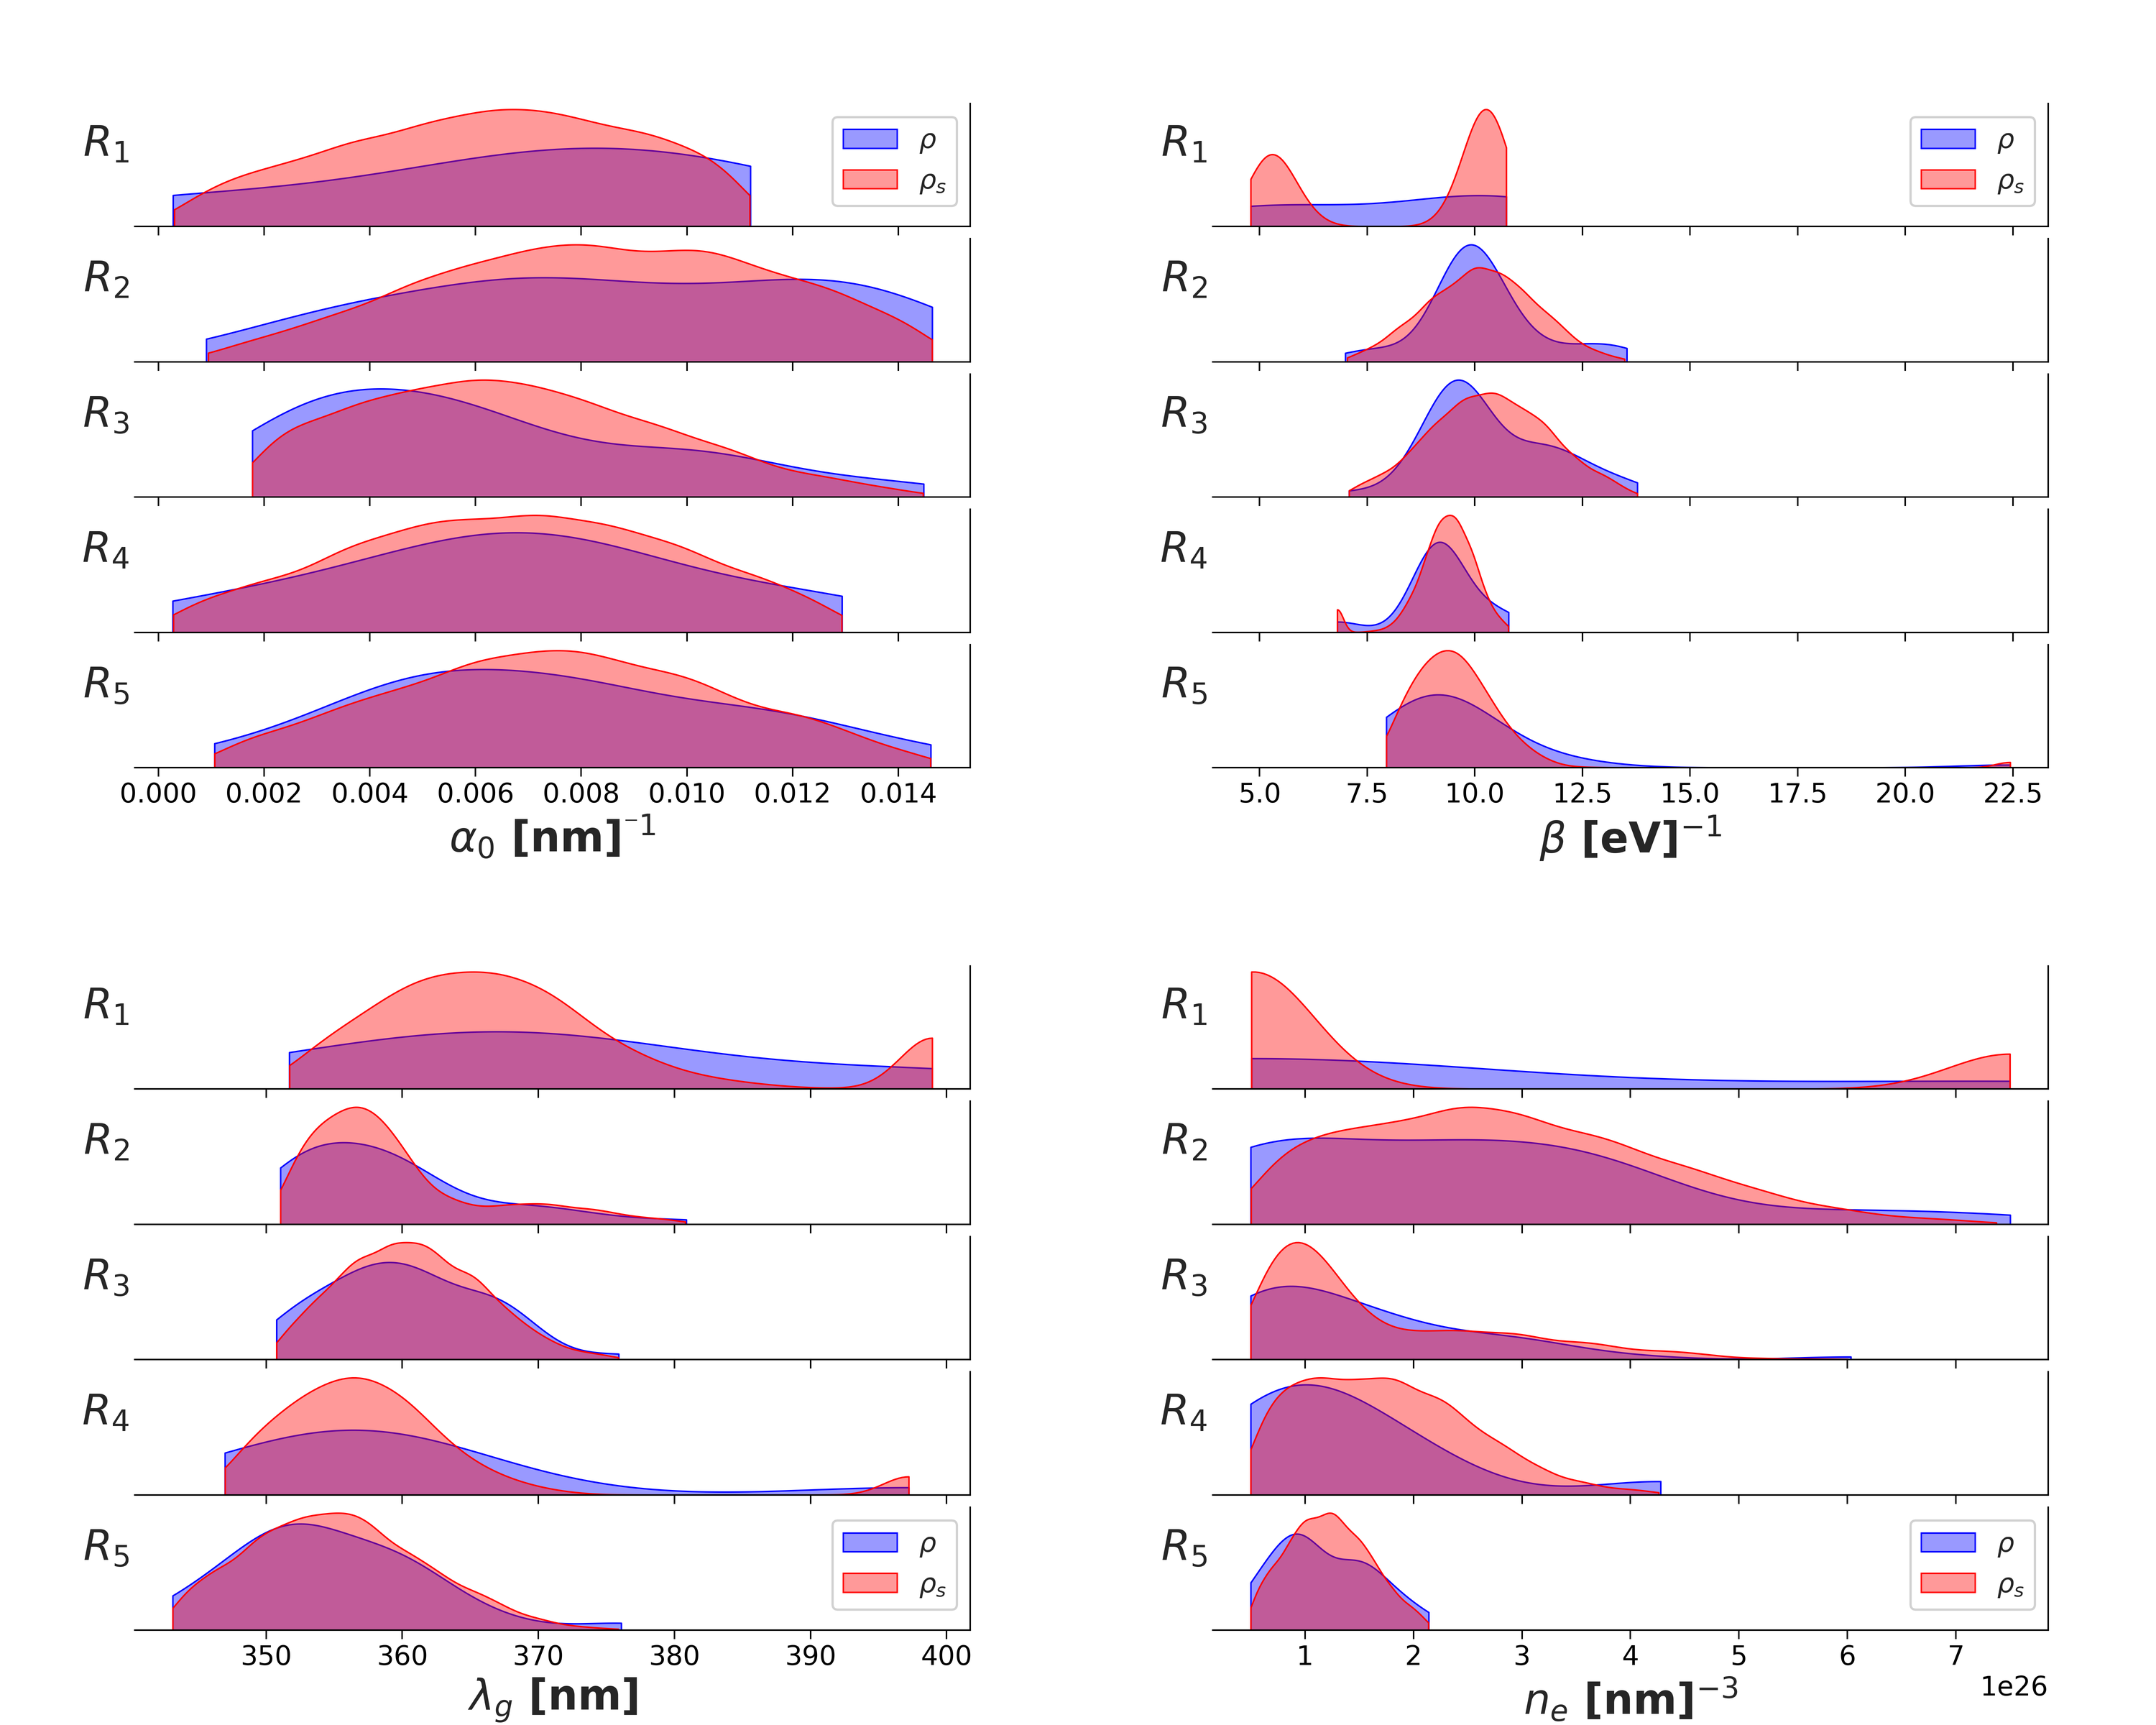

In [25]:
create_simple_grid(
    image_folder="/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/images/ridger_plot/Absorcion/",
    rows=2,  # 3 rows
    cols=2,  # 4 columns
    output_path="combined_absorcion.png",
    spacing=0,  # 5 pixels spacing
    scale_factor=0.5  # Reduce each image to 50% before creating grid
)

Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Scaling from 3000x2400 to 1500x1200
Grid created with 6 images
Grid size: 4500x2400 pixels
Saved to: combined_sellmeier.png


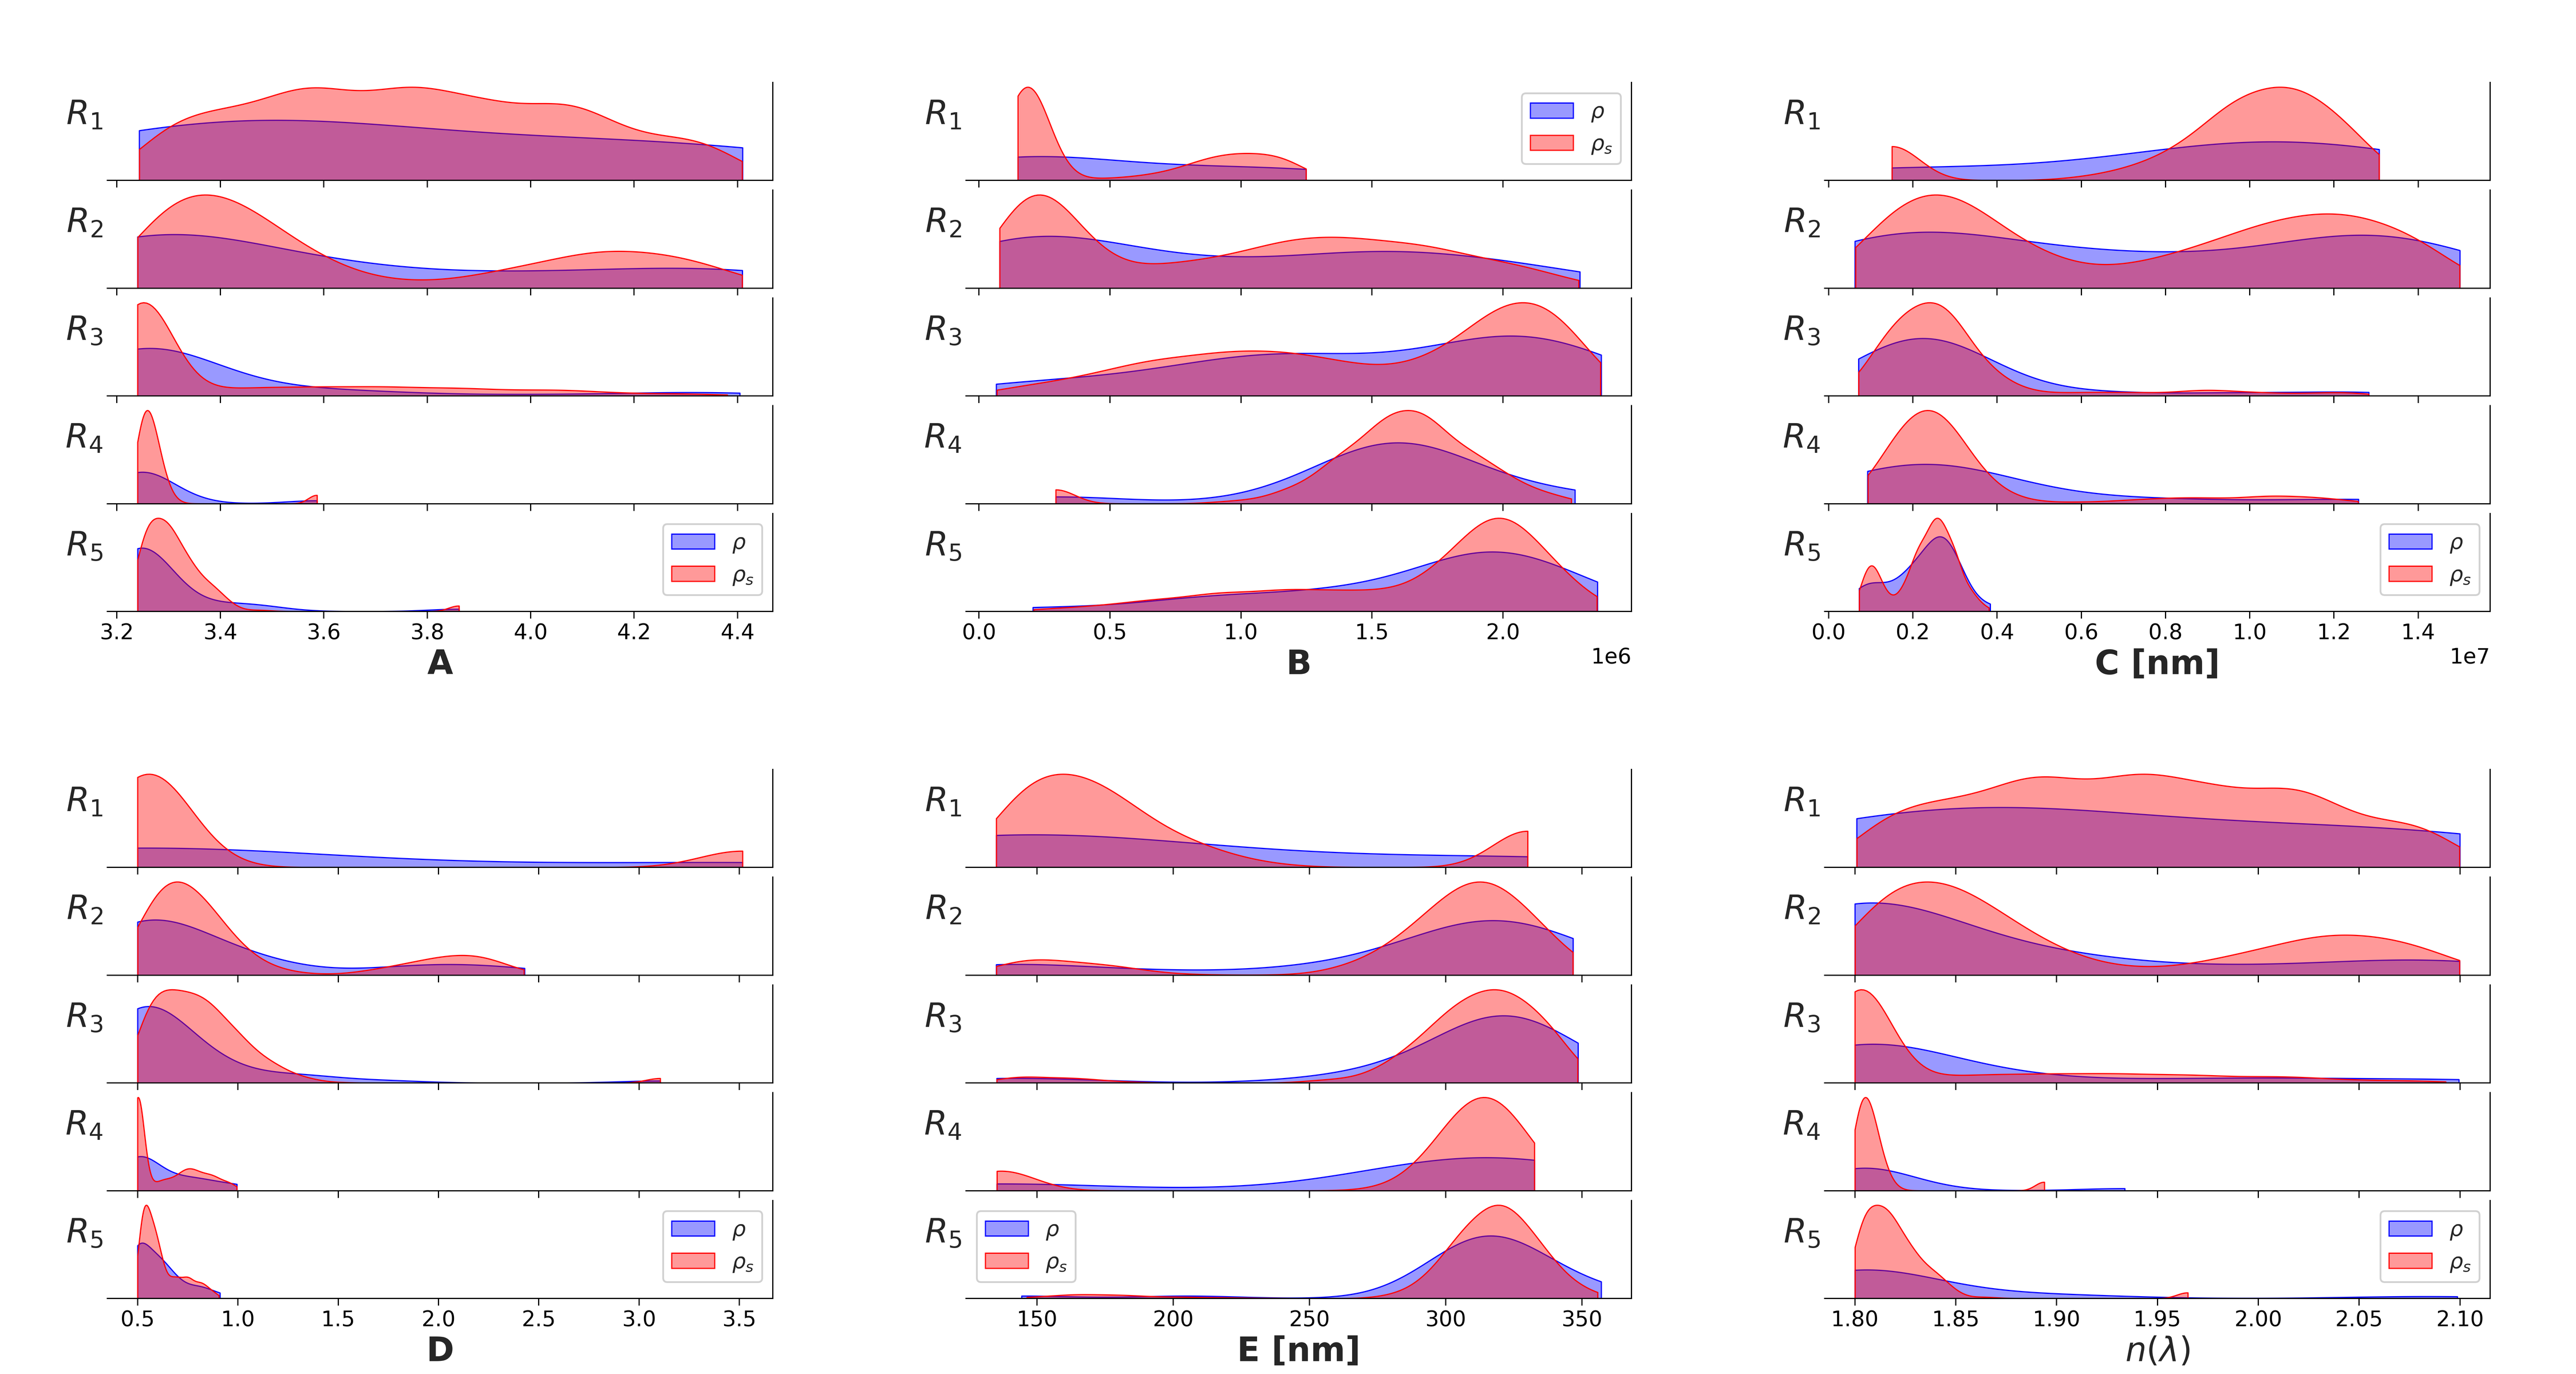

In [26]:
create_simple_grid(
    image_folder="/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/images/ridger_plot/Sellmeier/",
    rows=2,  # 3 rows
    cols=3,  # 4 columns
    output_path="combined_sellmeier.png",
    spacing=0,  # 5 pixels spacing
    scale_factor=0.5  # Reduce each image to 50% before creating grid
)

In [27]:
_all_thickness = [ np.array(t) for t in all_thickness ]

## Spectrums for Regions

In [ ]:
dataframes = [
    pd.read_parquet('/home/alan-amaro/Documents/Thesis_New_Data/DataBins/bin_{}.parquet'.format(i)) for i in range(0,5)
]

In [ ]:
n = 0

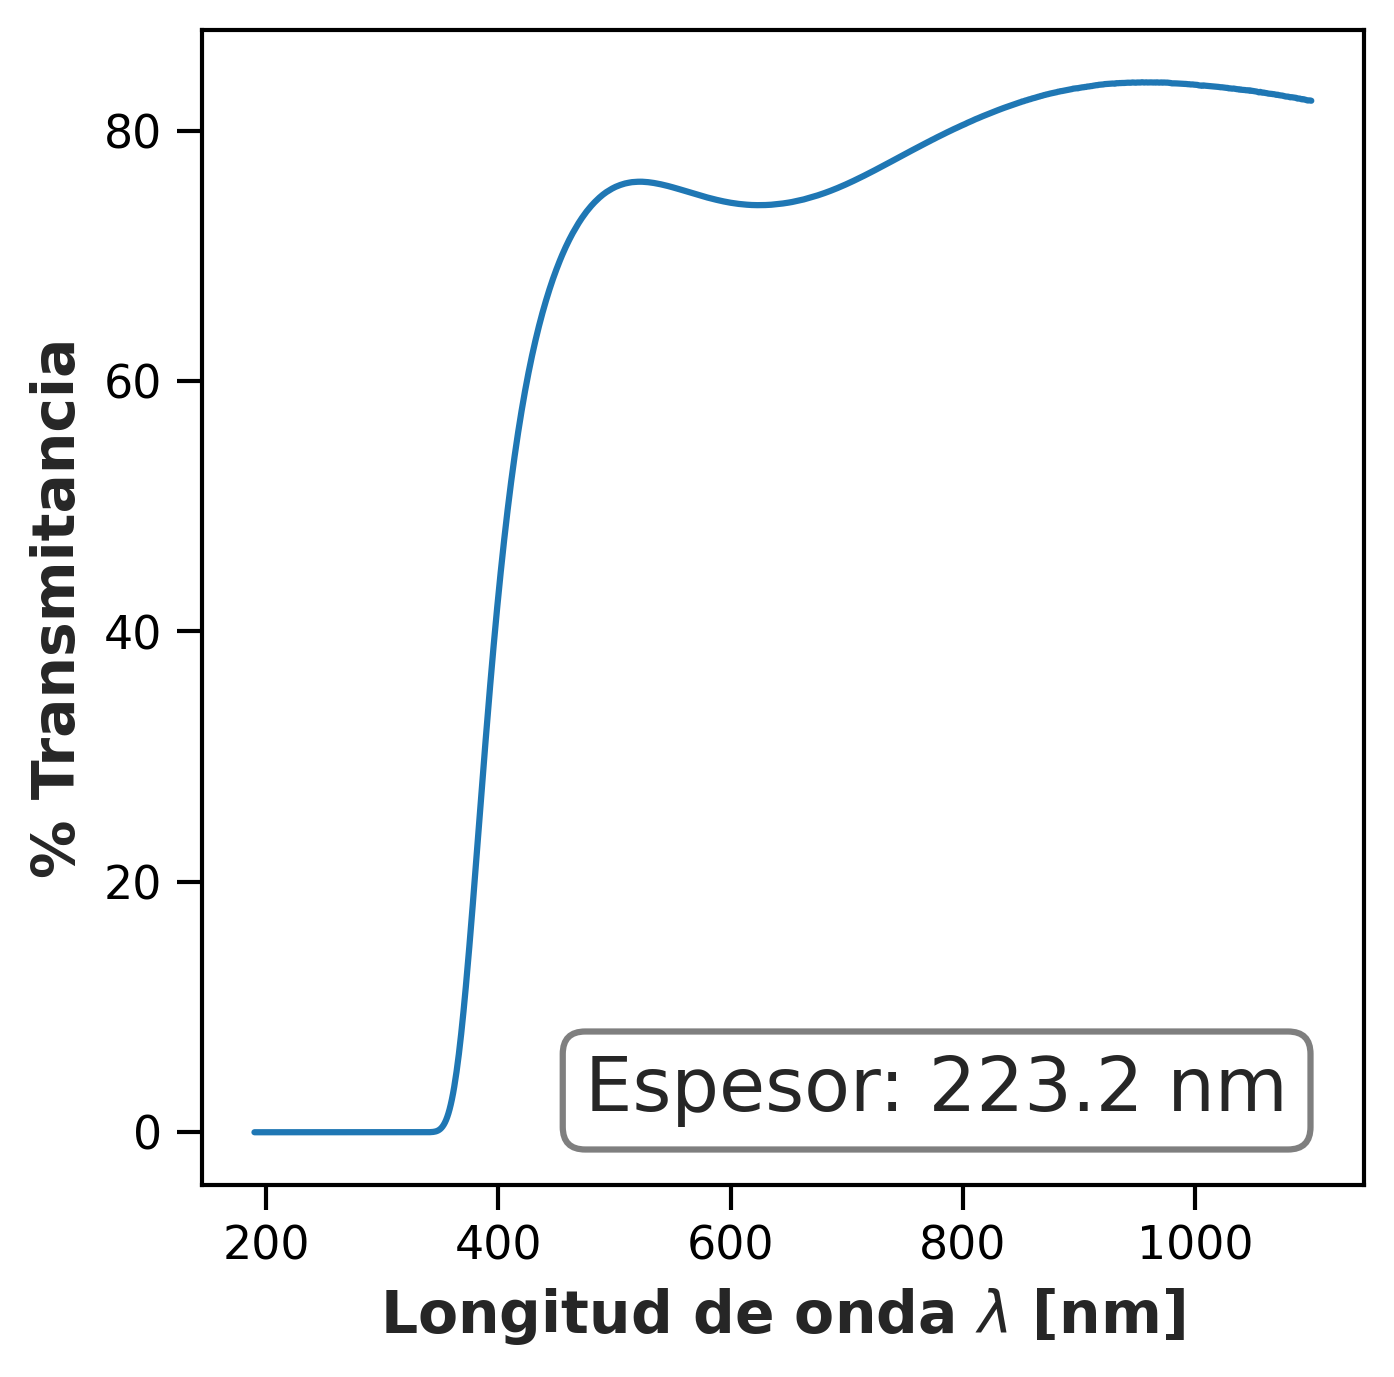

In [ ]:
plt.figure(figsize = (5,5) )
x = np.arange(190, 1101, 1)

# Add text label for thickness
thickness_value = dataframes[0]['Espesor'][n]  # or however you access thickness
plt.text(0.33, 0.05, 'Espesor: {:.1f} nm'.format(thickness_value),
         transform=plt.gca().transAxes,
         verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize = 18)

plt.plot(x, dataframes[0]['Espectro'][n])
plt.xlabel('Longitud de onda $\lambda$ [nm]')
plt.ylabel('% Transmitancia')
plt.savefig('./images/spectrum_thickness/r1.png')
plt.show()

In [ ]:
_all_thickness = np.hstack(_all_thickness)
_all_thickness.shape

NameError: name '_all_thickness' is not defined

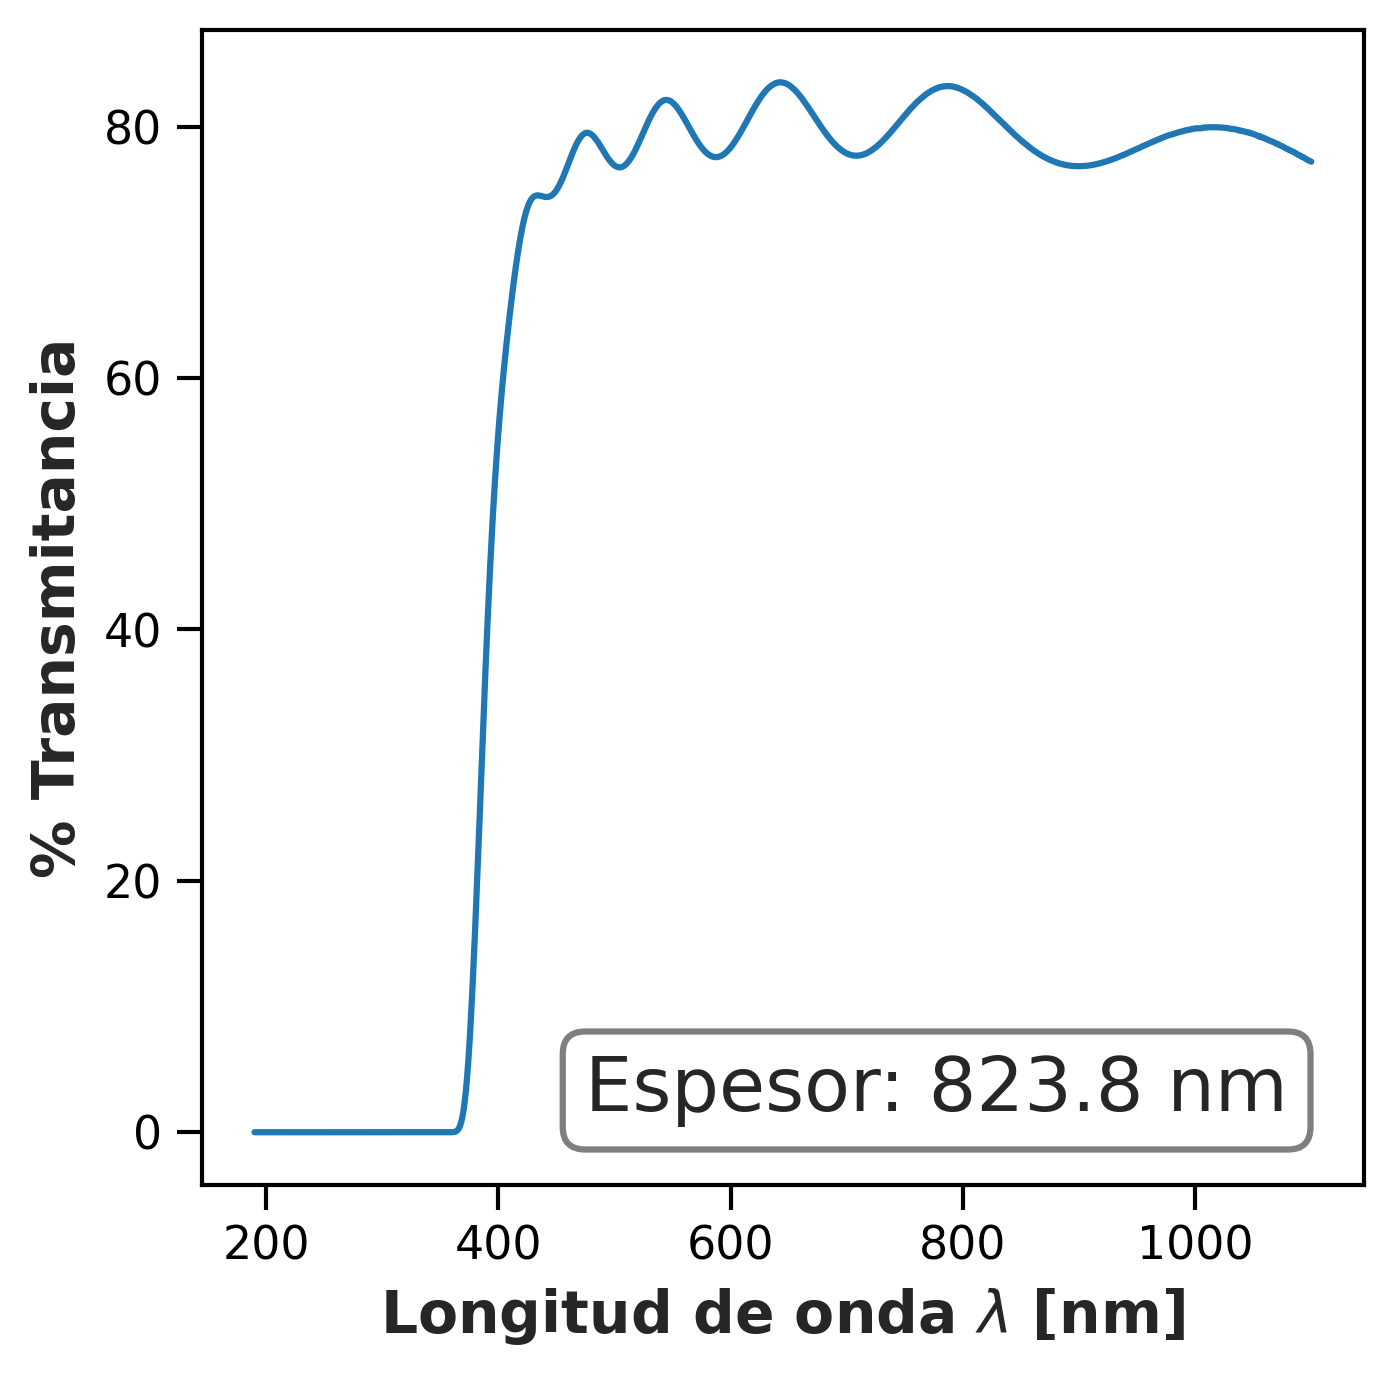

In [ ]:
plt.figure(figsize = (5,5) )

thickness_value = dataframes[2]['Espesor'][n]  # or however you access thickness
plt.text(0.33, 0.05, 'Espesor: {:.1f} nm'.format(thickness_value),
         transform=plt.gca().transAxes,
         verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize = 18)

plt.plot(x, dataframes[2]['Espectro'][n])
plt.xlabel('Longitud de onda $\lambda$ [nm]')
plt.ylabel('% Transmitancia')
plt.savefig('./images/spectrum_thickness/r3.png')
plt.show()

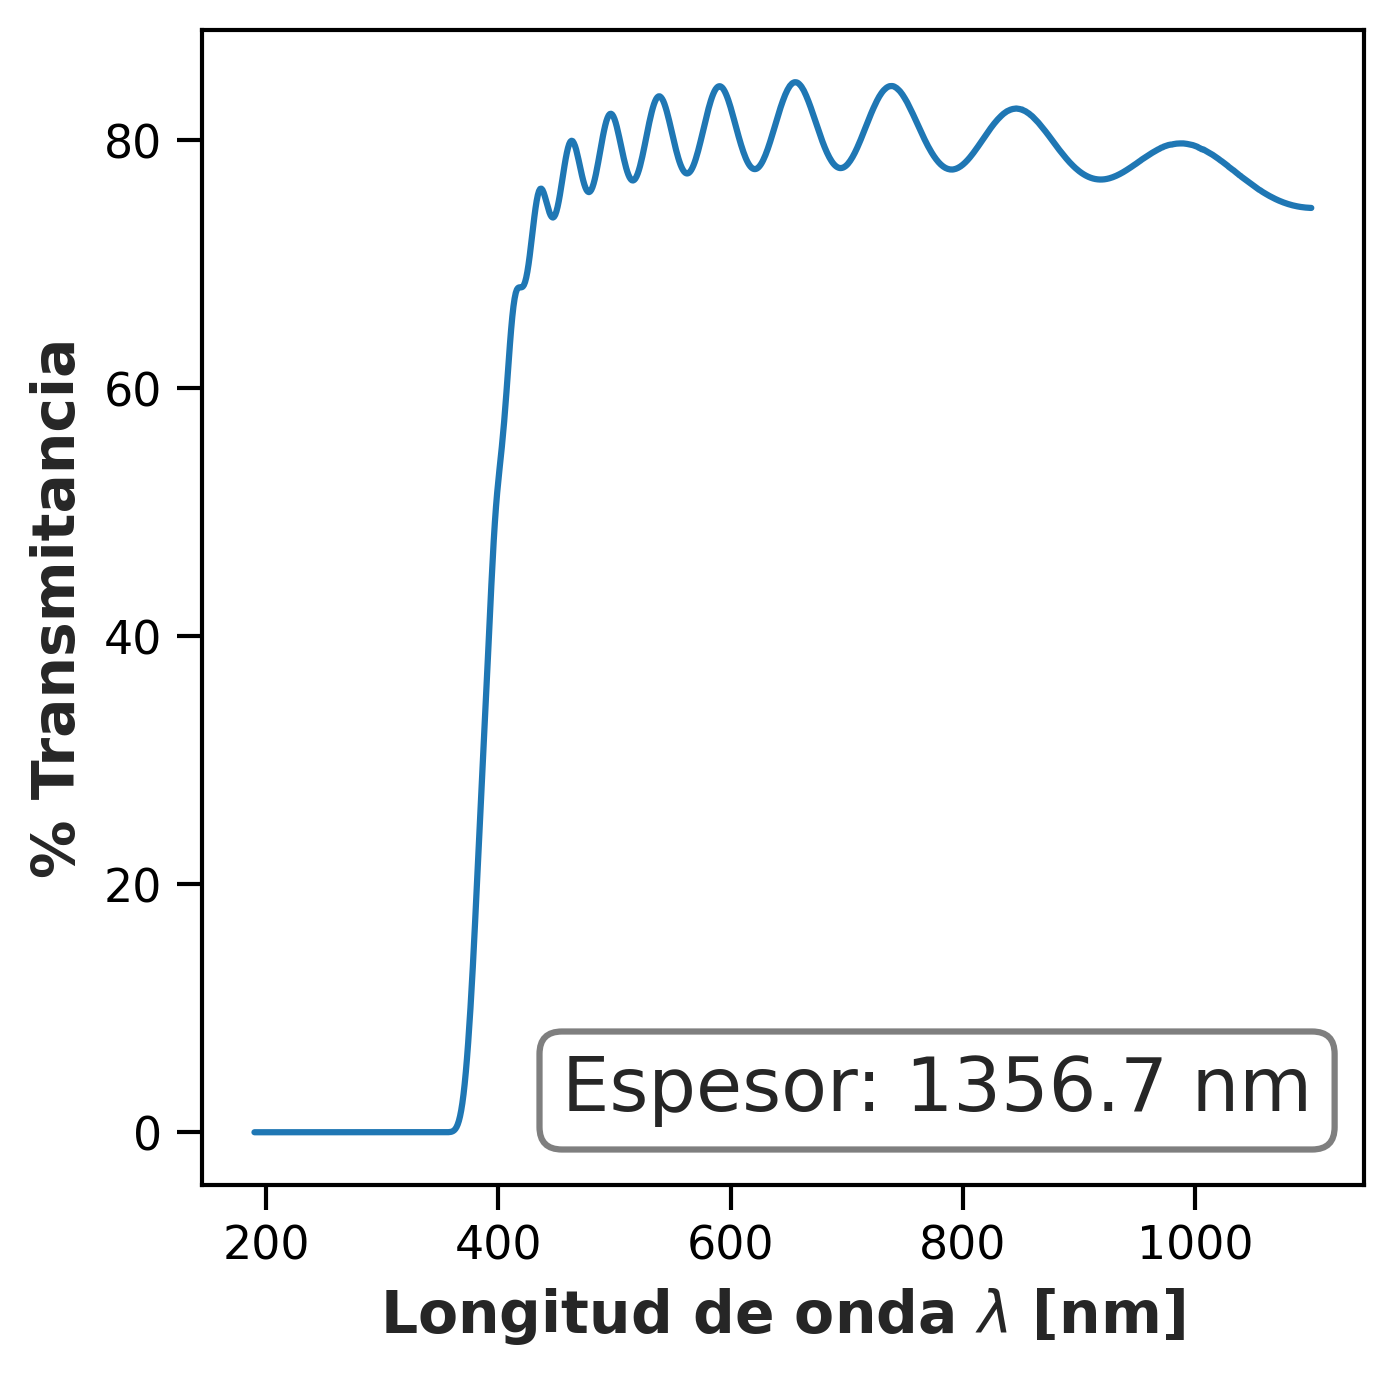

In [ ]:
plt.figure(figsize = (5,5) )

thickness_value = dataframes[4]['Espesor'][n]  # or however you access thickness
plt.text(0.31, 0.05, 'Espesor: {:.1f} nm'.format(thickness_value),
         transform=plt.gca().transAxes,
         verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize = 18)

plt.plot(x, dataframes[4]['Espectro'][n])
plt.xlabel('Longitud de onda $\lambda$ [nm]')
plt.ylabel('% Transmitancia')
plt.savefig('./images/spectrum_thickness/r5.png')
plt.show()

Scaling from 1500x1500 to 750x750
Scaling from 1500x1500 to 750x750
Scaling from 1500x1500 to 750x750
Grid created with 3 images
Grid size: 2250x750 pixels
Saved to: combined_spectrums.png


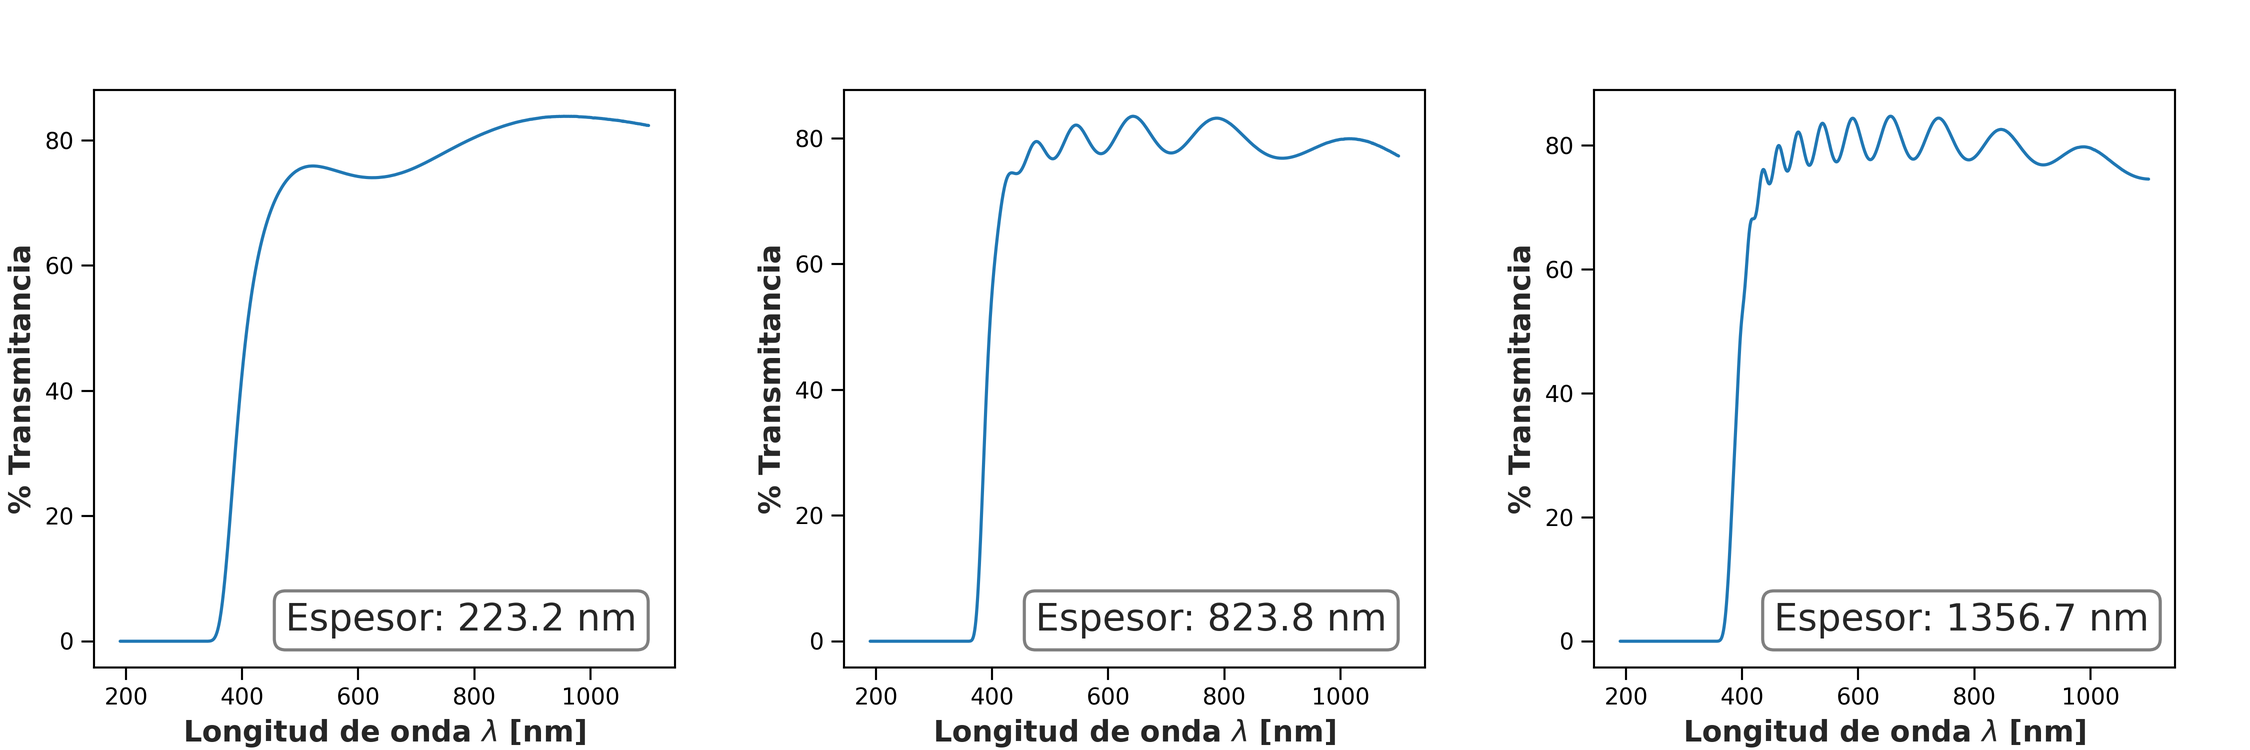

In [ ]:
create_simple_grid(
    image_folder="./images/spectrum_thickness/",
    rows=1,  # 3 rows
    cols=3,  # 4 columns
    output_path="combined_spectrums.png",
    spacing=0,  # 5 pixels spacing
    scale_factor=0.5  # Reduce each image to 50% before creating grid
)

In [ ]:
_params = [ np.array(p) for p in params ]

In [ ]:
_params = np.vstack(_params)
_params.shape

(145, 12)

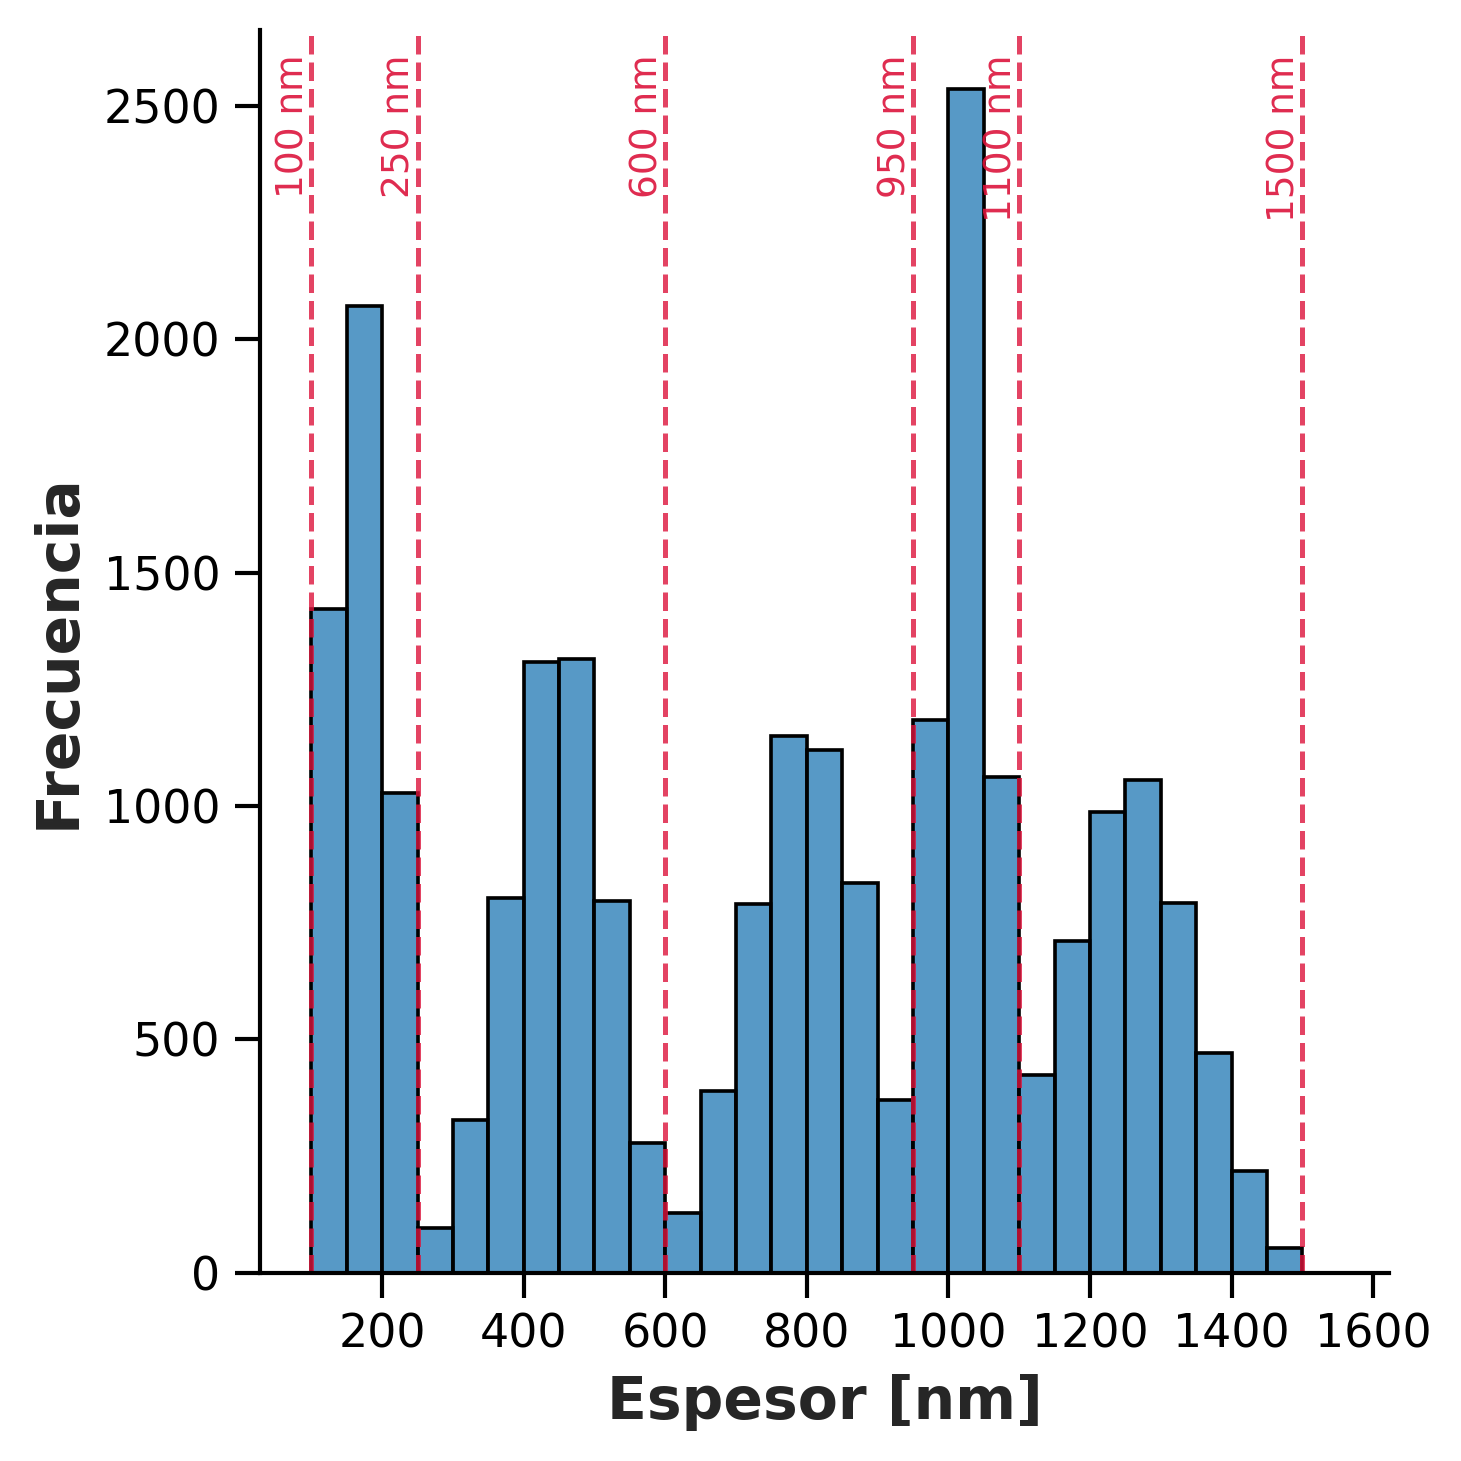

In [ ]:
# Determine the range of the data
min_thickness = 100
max_thickness = 1500
bins = np.arange(min_thickness, max_thickness + 100, 50)

plt.figure(figsize=(5, 5))

# Create histogram with seaborn
ax = sns.histplot(_all_thickness, bins=bins)


# Add vertical lines with labels
vline_positions = [100, 250, 600, 950, 1100, 1500]
vline_labels = ['100 nm', '250 nm', '600 nm', '950 nm', '1100 nm', '1500 nm']

for i, label in zip(vline_positions, vline_labels):
    plt.axvline(i, color='crimson', linestyle='--', linewidth=1.2,
                alpha=0.8)
    # Add text labels rotated vertically
    plt.text(i, plt.ylim()[1] * 0.98, label, rotation=90,
             verticalalignment='top', horizontalalignment='right',
             fontsize=9, color='crimson', alpha=0.9)

# Labels
plt.xlabel('Espesor [nm]')
plt.ylabel('Frecuencia')

# Clean spines
sns.despine()

plt.tight_layout()
plt.savefig('./images/spectrum_thickness/allthickness.png')
plt.show()

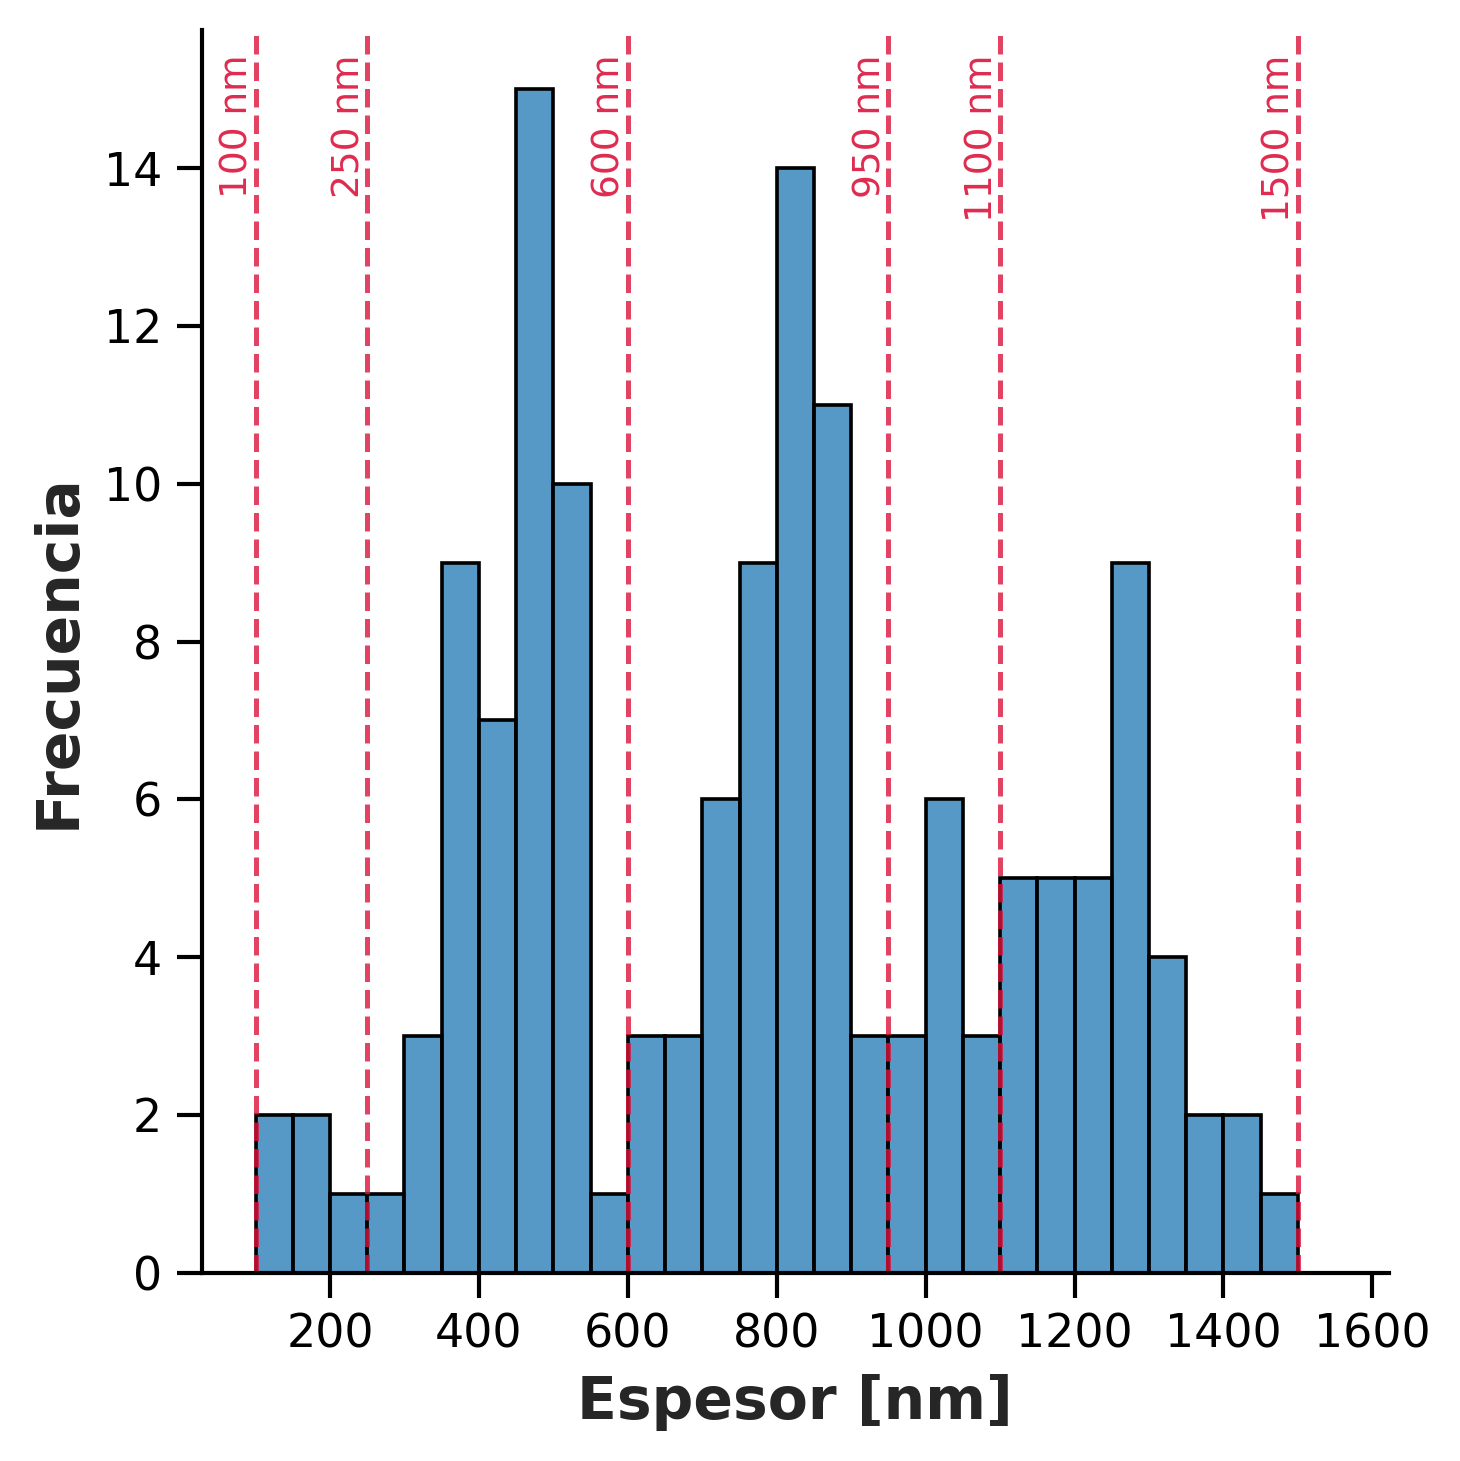

In [ ]:
# Determine the range of the data
min_thickness = 100
max_thickness = 1500
bins = np.arange(min_thickness, max_thickness + 100, 50)

plt.figure(figsize=(5, 5))

# Create histogram with seaborn
ax = sns.histplot(_params[:, 0], bins=bins)


# Add vertical lines with labels
vline_positions = [100, 250, 600, 950, 1100, 1500]
vline_labels = ['100 nm', '250 nm', '600 nm', '950 nm', '1100 nm', '1500 nm']

for i, label in zip(vline_positions, vline_labels):
    plt.axvline(i, color='crimson', linestyle='--', linewidth=1.2,
                alpha=0.8)
    # Add text labels rotated vertically
    plt.text(i, plt.ylim()[1] * 0.98, label, rotation=90,
             verticalalignment='top', horizontalalignment='right',
             fontsize=9, color='crimson', alpha=0.9)

# Labels
plt.xlabel('Espesor [nm]')
plt.ylabel('Frecuencia')

# Clean spines
sns.despine()

plt.tight_layout()
plt.savefig('./images/spectrum_thickness/145thickness.png')
plt.show()

Scaling from 1500x1500 to 750x750
Scaling from 1500x1500 to 750x750
Grid created with 2 images
Grid size: 1500x750 pixels
Saved to: combined_hist_thickness.png


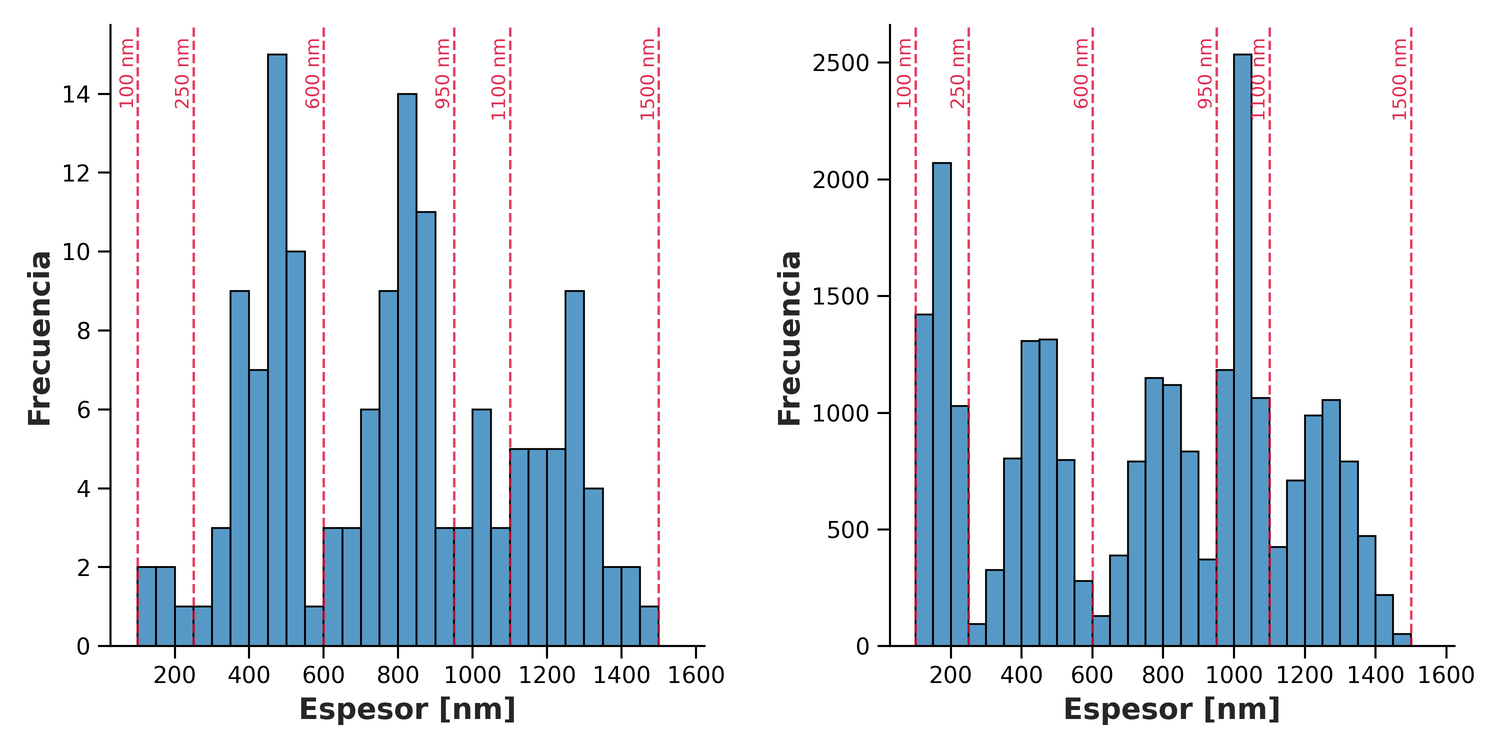

In [ ]:
create_simple_grid(
    image_folder="./images/spectrum_thickness/",
    rows=1,  # 3 rows
    cols=2,  # 4 columns
    output_path="combined_hist_thickness.png",
    spacing=0,  # 5 pixels spacing
    scale_factor=0.5  # Reduce each image to 50% before creating grid
)